This notebook retains only the drifters observations within the SWOT swath, and within a 12hr window around the SWOT overpass time.

In [1]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import xarray as xr

In [2]:
drifter_ds = xr.open_zarr("data/drifters_drogue15m_CalVal.zarr").compute()

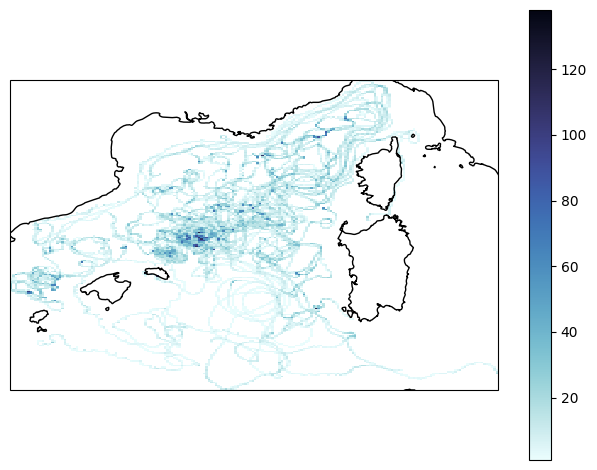

In [3]:
fig = plt.figure()
ax = fig.add_subplot(projection=ccrs.PlateCarree())

im = ax.hist2d(drifter_ds.longitude, drifter_ds.latitude, bins=200, cmap=cmo.ice_r, cmin=1)[-1]

fig.colorbar(im, ax=ax, orientation="vertical")
ax.coastlines()

fig.tight_layout()

plt.show()

In [4]:
def filter_drifter_observations(drifter_ds, pass_ds, time_cutoff_hours=6):
    def wrap_lon(lon, lon_ref):
        return lon_ref + ((lon - lon_ref + 180) % 360) - 180
    
    # 1 - Spatial filter: keep only drifter observations inside SWOT swathes (left or right)
    def swath_mask_griddata(pass_ds, drifter_ds, side):
        if side == "left":
            pass_ds_ = pass_ds.where((pass_ds.cross_track_distance < 1).compute(), drop=True)
        elif side == "right":
            pass_ds_ = pass_ds.where((pass_ds.cross_track_distance > 1).compute(), drop=True)
        else:
            raise ValueError("side must be 'left' or 'right'")

        swath_lon = pass_ds_.longitude.values.ravel()
        swath_lat = pass_ds_.latitude.values.ravel()

        lon_ref = np.nanmean(swath_lon)
        swath_lon = wrap_lon(swath_lon, lon_ref)

        points = np.column_stack([swath_lon, swath_lat])
        values = np.sum(np.isfinite(pass_ds_.ssha_filtered), axis=0).values.ravel().astype(float)
        values[values == 0] = np.nan  # set outside swath to nan

        drifters_lon = wrap_lon(drifter_ds.longitude.values, lon_ref)
        drifters_lat = drifter_ds.latitude.values
        drifters_points = np.column_stack([drifters_lon, drifters_lat])

        interp = griddata(points, values, drifters_points, method="linear", fill_value=np.nan)

        return np.isfinite(interp)

    drifter_ds["drifter_id"] = drifter_ds.drifter_id.astype(object).astype(str)
    drifter_ds["drifter_type"] = drifter_ds.drifter_type.astype(object).astype(str)

    # split left/right swath
    mask_left  = swath_mask_griddata(pass_ds, drifter_ds, "left")
    mask_right = swath_mask_griddata(pass_ds, drifter_ds, "right")

    is_inside = mask_left | mask_right

    drifter_ds = drifter_ds.where(xr.DataArray(is_inside, dims=["points"]), drop=True)

    # 2 - Temporal filter: keep only drifter observations within time_cutoff_hours of SWOT overpass time

    # 2.1 - Remove before / after dates
    pass_time = pass_ds.time.values.astype("datetime64[ns]")

    pass_time = pass_time[~np.isnat(pass_time)]

    swot_start_time = pass_time.min()
    swot_end_time = pass_time.max()

    is_during_calval = (drifter_ds.time.values >= swot_start_time) & (drifter_ds.time.values <= swot_end_time)

    drifter_ds = drifter_ds.where(xr.DataArray(is_during_calval, dims=["points"]), drop=True)

    # 2.2 - Find closest SWOT pixel to each drifter observation
    pass_lat = pass_ds.latitude.values
    pass_lon = pass_ds.longitude.values

    n_num_line = pass_lat.shape[-1]

    lon_ref = np.nanmean(pass_lon.ravel())

    points = np.column_stack([wrap_lon(pass_lon.ravel(), lon_ref), pass_lat.ravel()])

    tree = cKDTree(points)

    drifters_points = np.column_stack([wrap_lon(drifter_ds.longitude.values, lon_ref), drifter_ds.latitude.values])

    spatial_idx = tree.query(drifters_points)[1]  # index of closest SWOT pixel
    num_line_idx = spatial_idx % n_num_line  # corresponding along-swath index

    # 2.3 - Find closest time in SWOT data to each drifter observation and filter based on time cutoff
    obs_time_np = drifter_ds.time.values.astype("datetime64[ns]")

    pass_time = pass_ds.time.values.astype("datetime64[ns]")

    t_series = pass_time[:, num_line_idx]

    time_diff = np.min(np.abs((t_series - obs_time_np) / np.timedelta64(1, "s")), axis=0)

    time_cutoff_seconds = time_cutoff_hours * 3600
    is_close_enough = time_diff <= time_cutoff_seconds
    
    drifter_ds = drifter_ds.where(xr.DataArray(is_close_enough, dims=["points"]), drop=True)

    return drifter_ds

In [5]:
pass003_ds = xr.open_zarr("data/SWOT_L3_Expert_v3_0_pass003.zarr")
pass016_ds = xr.open_zarr("data/SWOT_L3_Expert_v3_0_pass016.zarr")

In [6]:
drifter003_ds = filter_drifter_observations(drifter_ds, pass003_ds, time_cutoff_hours=6)
drifter016_ds = filter_drifter_observations(drifter_ds, pass016_ds, time_cutoff_hours=6)

In [7]:
drifter003_ds.to_zarr("data/drifters003_drogue15m_swath_CalVal.zarr", mode="w")
drifter016_ds.to_zarr("data/drifters016_drogue15m_swath_CalVal.zarr", mode="w")

/Users/bertrava/miniforge3/envs/swot-cyclogeo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Users/bertrava/miniforge3/envs/swot-cyclogeo/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [8]:
drifter_ds = xr.concat([drifter003_ds, drifter016_ds], dim="points")

In [9]:
drifter_ds.points.size, drifter003_ds.points.size, drifter016_ds.points.size

(11880, 9146, 2734)

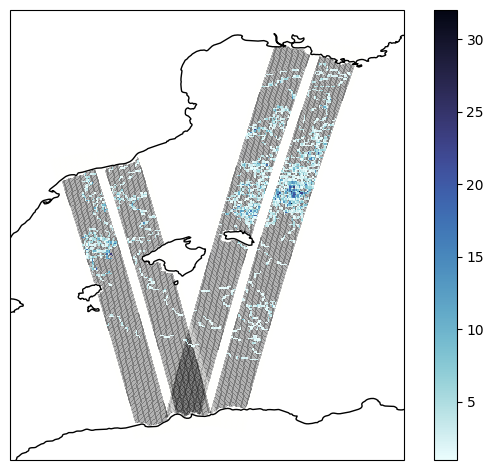

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection=ccrs.PlateCarree())

pass003_left_ds = pass003_ds.where((pass003_ds.cross_track_distance < 0).compute(), drop=True)
pass003_right_ds = pass003_ds.where((pass003_ds.cross_track_distance > 0).compute(), drop=True)
is_ssh003_finite_left = np.sum(np.isfinite(pass003_left_ds.ssha_filtered), axis=0) > 0
is_ssh003_finite_right = np.sum(np.isfinite(pass003_right_ds.ssha_filtered), axis=0) > 0
_ = ax.pcolormesh(
    pass003_left_ds.longitude,
    pass003_left_ds.latitude,
    is_ssh003_finite_left,
    transform=ccrs.PlateCarree(),
    alpha=0.3,
    cmap=cmo.gray_r,
)
_ = ax.pcolormesh(
    pass003_right_ds.longitude,
    pass003_right_ds.latitude,
    is_ssh003_finite_right,
    transform=ccrs.PlateCarree(),
    alpha=0.3,
    cmap=cmo.gray_r,
)
pass016_left_ds = pass016_ds.where((pass016_ds.cross_track_distance < 0).compute(), drop=True)
pass016_right_ds = pass016_ds.where((pass016_ds.cross_track_distance > 0).compute(), drop=True)
is_ssh016_finite_left = np.sum(np.isfinite(pass016_left_ds.ssha_filtered), axis=0) > 0
is_ssh016_finite_right = np.sum(np.isfinite(pass016_right_ds.ssha_filtered), axis=0) > 0
_ = ax.pcolormesh(
    pass016_left_ds.longitude,
    pass016_left_ds.latitude,
    is_ssh016_finite_left,
    transform=ccrs.PlateCarree(),
    alpha=0.3,
    cmap=cmo.gray_r,
)
_ = ax.pcolormesh(
    pass016_right_ds.longitude,
    pass016_right_ds.latitude,
    is_ssh016_finite_right,
    transform=ccrs.PlateCarree(),
    alpha=0.3,
    cmap=cmo.gray_r,
)

im = ax.hist2d(drifter_ds.longitude, drifter_ds.latitude, bins=200, cmap=cmo.ice_r, cmin=1)[-1]

fig.colorbar(im, ax=ax, orientation="vertical")
ax.coastlines()
ax.set_extent([0, 7, 36, 44], crs=ccrs.PlateCarree())

fig.tight_layout()

plt.show()

In [11]:
cycle_times_003 = pass003_ds.time.mean(dim=["num_lines"]).values
cycle_times_016 = pass016_ds.time.mean(dim=["num_lines"]).values

cycle_nums_003 = pass003_ds.cycle_num.values
cycle_nums_016 = pass016_ds.cycle_num.values

In [ ]:
delta_003 = drifter003_ds.time.values[None, :] - cycle_times_003[:, None]
delta_003 = delta_003.astype("timedelta64[s]").astype(float)

delta_016 = drifter016_ds.time.values[None, :] - cycle_times_016[:, None]
delta_016 = delta_016.astype("timedelta64[s]").astype(float)

idx_003 = np.nanargmin(np.abs(delta_003), axis=0)
idx_016 = np.nanargmin(np.abs(delta_016), axis=0)

In [13]:
idx_003, counts_003 = np.unique(idx_003, return_counts=True)
idx_016, counts_016 = np.unique(idx_016, return_counts=True)

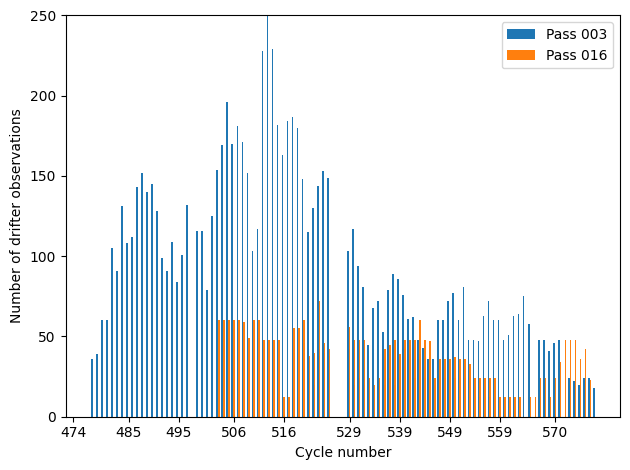

In [14]:
width = 1 / 3

fig, ax = plt.subplots()

ax.bar(cycle_nums_003[idx_003], counts_003, width, label="Pass 003")
ax.bar(cycle_nums_016[idx_016] + width, counts_016, width, label="Pass 016")

ax.set_ylabel("Number of drifter observations")
ax.set_xlabel("Cycle number")
ax.set_xticks(cycle_nums_003[::10] + width, cycle_nums_003.astype(str)[::10])
ax.legend()
ax.set_ylim(0, 250)

plt.tight_layout()

plt.show()